In [298]:
import numpy as np
import pandas as pd

In [299]:
#Normalizing per class
#Bootstrapping to generate new data for each class
#given a class, the set of functions should be able to generate new data
#create a save data method, that converts the dataframe to a CSV file

#eventual goal: run original data and bootstrapped data to obtain further insight 
#into accuracy and prediction 

In [300]:
#obtains numpy array from csv files
c0_1 = np.transpose(np.genfromtxt('C0_1.csv', delimiter=','))
c1_1 = np.transpose(np.genfromtxt('C1_1.csv', delimiter=','))
c1_2 = np.transpose(np.genfromtxt('C1_2.csv', delimiter=','))
c2_2 = np.transpose(np.genfromtxt('C2_2.csv', delimiter=','))
c3_1 = np.transpose(np.genfromtxt('C3_1.csv', delimiter=','))
c3_2 = np.transpose(np.genfromtxt('C3_2.csv', delimiter=','))
c4_1 = np.transpose(np.genfromtxt('C4_1.csv', delimiter=','))
c4_2 = np.transpose(np.genfromtxt('C4_2.csv', delimiter=','))
phsh = np.transpose(np.genfromtxt('PhSH.csv', delimiter=','))

In [301]:
#converts data into dataframe
dfc0_1 = pd.DataFrame(data = c0_1[1:, :],
                  columns = c0_1[0, :])
dfc1_1 = pd.DataFrame(data = c1_1[1:, :],
                  columns = c1_1[0, :])
dfc1_2 = pd.DataFrame(data = c1_2[1:, :],
                  columns = c1_2[0, :])
dfc2_2 = pd.DataFrame(data = c2_2[1:, :],
                  columns = c2_2[0, :])
dfc3_1 = pd.DataFrame(data = c3_1[1:, :],
                  columns = c3_1[0, :])
dfc3_2 = pd.DataFrame(data = c3_2[1:, :],
                  columns = c3_2[0, :])
dfc4_1 = pd.DataFrame(data = c4_1[1:, :],
                  columns = c4_1[0, :])
dfc4_2 = pd.DataFrame(data = c4_2[1:, :],
                  columns = c4_2[0, :])
dfphsh = pd.DataFrame(data = phsh[1:, :],
                  columns = phsh[0, :])

In [302]:
#sample what dataframe looks like
#Top row is wavelength and every row after that is one spectra (one measurement)
dfc0_1

,NaN,1464.236328,1463.174805,1462.113281,1461.050781,1459.989258,1458.926758,1457.864258,1456.801758,1455.738281,...,285.579102,284.278320,282.976563,281.673828,280.372070,279.069336,277.766602,276.462891,275.160156,273.855469
0,7.851468,34.419216,23.216547,30.838341,-3.935156,8.364193,-7.595981,11.729235,-13.663581,-36.707447,...,-2.284379,5.899069,19.754951,50.799076,16.479366,22.391092,47.402542,55.048630,1.233888,-8.547133
1,5.250309,31.423407,10.443404,1.247279,20.308502,25.242231,23.117157,-9.592113,-18.761225,0.300912,...,-6.973229,-7.286257,28.824547,22.610033,-0.943309,11.909813,24.688627,4.778110,2.069305,-14.136386
2,-21.775425,-14.891433,-10.501033,19.718552,-1.933541,-33.061092,11.067792,17.470758,40.277981,23.034729,...,-8.986943,8.056575,-38.395119,-10.054530,0.889819,5.957412,7.073138,-7.275029,7.041735,-5.615203
3,-10.636886,-9.228920,-5.560400,-16.056335,29.920977,2.878949,-7.710040,9.909071,-10.147979,47.391602,...,27.996864,3.434117,7.611238,28.988346,6.130531,-3.360867,-18.679657,13.889758,38.701435,-13.277476
4,-13.345345,8.862473,14.502220,-3.419907,-0.158765,5.441658,-21.918407,30.719112,-3.716548,30.059006,...,12.327760,-4.998731,12.130102,-26.555725,21.039150,30.098259,8.323075,26.707462,2.757470,-7.904505
5,-32.623310,17.785582,37.333462,-30.385363,-15.808859,10.401298,5.887269,3.608669,-22.309031,19.882719,...,9.932615,-1.757609,5.553111,6.885777,23.365248,-12.205905,15.334741,2.342937,-33.886974,-16.661263
6,7.991025,35.160137,-31.870722,-25.815851,27.384039,42.965111,56.245659,-1.008689,5.331272,-4.741733,...,39.911995,11.791382,2.784984,39.758667,40.138958,3.943062,2.191001,38.691029,48.210880,-19.097462
7,16.394936,-20.737921,-3.763145,41.469196,1.939507,-21.092167,12.372858,-5.932422,48.702156,23.353569,...,-9.577457,12.142375,45.146553,-0.823726,-0.936388,44.761917,3.840818,18.304893,44.006790,-7.289328
8,7.709911,26.840879,-5.909978,-0.982015,-3.126495,-7.631850,-5.082425,-0.187850,21.165770,14.281119,...,9.099441,-9.592519,-11.201802,-1.506979,-1.629921,-5.821752,1.268119,4.273265,12.788663,-5.809623
9,20.349304,39.769035,-11.532964,-15.721723,-3.428626,20.628151,-9.451192,14.597514,-17.822811,-3.190404,...,6.443680,13.942500,23.203989,13.101148,-25.949394,21.213827,12.540672,-7.817672,6.179360,-4.950736


In [303]:
#normalizing data
def normalize(dataframe):
    means = np.mean(dataframe, axis=0)
    sigma = np.std(dataframe, axis=0)
    return (dataframe-means)/sigma

dfc0_1 = normalize(dfc0_1.iloc[:, :1014])
#dfc0_1['Type'] = 51 * ['c0']
#dfc0_1

In [304]:
dfc0_1.columns

Index([        nan, 1464.236328, 1463.174805, 1462.113281, 1461.050781,
       1459.989258, 1458.926758, 1457.864258, 1456.801758, 1455.738281,
       ...
        286.880859,  285.579102,   284.27832,  282.976563,  281.673828,
         280.37207,  279.069336,  277.766602,  276.462891,  275.160156],
      dtype='float64', length=1014)

In [305]:
#generates random indices 
#count is how many indices and max is highest index possible
def rand_nums(count, max):
    return np.random.randint(0, max, size=count)
#generates one random single data point across the 1015 wavelengths
def gen_datum(dataframe):
    datum = {}
    for column_name in dataframe.columns:
        indices = rand_nums(10, len(dataframe))
        column_sample = dataframe[column_name].values[indices]
        datum[column_name] = [np.mean(column_sample)]
    return pd.DataFrame(datum)
#generates x data points using gen_datum function
def gen_x_data(dataframe, x):
    all_data = pd.DataFrame({})
    for i in range(x):
        all_data = pd.concat([gen_datum(dataframe), all_data], ignore_index=True)
    return all_data

result = gen_datum(dfc0_1)
gen_x_data(dfc0_1, 5)

,NaN,1464.236328,1463.174805,1462.113281,1461.050781,1459.989258,1458.926758,1457.864258,1456.801758,1455.738281,...,286.880859,285.579102,284.278320,282.976563,281.673828,280.372070,279.069336,277.766602,276.462891,275.160156
0,-0.137037,0.039485,0.400489,0.141066,-0.411415,-0.620917,0.151489,0.097013,0.004348,0.469143,...,-0.610993,-0.291109,0.263253,0.330934,-0.229167,-0.092896,0.075947,-0.198285,-0.273243,0.069887
1,0.210031,0.225365,-0.240617,0.153883,0.585691,-0.163932,-0.167976,0.075298,0.318734,0.434207,...,0.504447,0.074370,0.015174,0.601507,-0.599502,0.407947,-0.393078,0.072661,0.436913,0.231222
2,-0.732906,-0.064516,-0.112063,-0.140162,0.157664,0.045963,-0.136130,-0.387602,0.534814,0.412254,...,-0.224768,0.028246,0.480123,0.400688,-0.554553,-0.058284,0.395576,0.047198,0.380051,-0.327832
3,0.031912,-0.373642,0.768955,-0.548848,-0.073660,0.260447,0.442088,-0.118348,-0.156857,-0.228043,...,0.402333,0.029496,0.685813,-0.463293,-0.211566,0.352853,0.824740,0.020987,0.442408,-0.179311
4,-0.041470,0.183256,-0.185175,-0.344483,0.656925,-0.451991,0.077848,-0.216751,0.235855,0.738514,...,-0.171392,0.249286,0.009135,-0.181771,-0.305855,-0.085987,-0.342763,0.664500,-0.443495,0.222174


In [306]:
#generates each dataframe separately (5 rows each)
#and appends the type to the end of the row
c0_1_rand = gen_x_data(dfc0_1, 5)
c0_1_rand['Type'] = 'c0'
c1_1_rand = gen_x_data(dfc1_1, 5)
c1_1_rand['Type'] = 'c1'
c1_2_rand = gen_x_data(dfc1_2, 5)
c1_2_rand['Type'] = 'c1'
c2_2_rand = gen_x_data(dfc2_2, 5)
c2_2_rand['Type'] = 'c2'
c3_1_rand = gen_x_data(dfc3_1, 5)
c3_1_rand['Type'] = 'c3'
c3_2_rand = gen_x_data(dfc3_2, 5)
c3_2_rand['Type'] = 'c3'
c4_1_rand = gen_x_data(dfc4_1, 5)
c4_1_rand['Type'] = 'c4'
c4_2_rand = gen_x_data(dfc4_2, 5)
c4_2_rand['Type'] = 'c4'
phsh_rand = gen_x_data(dfphsh, 5)
phsh_rand['Type'] = 'phsh'

df_rand = pd.concat([c0_1_rand, c1_1_rand, c1_2_rand, c2_2_rand, c3_1_rand, c3_2_rand, c4_1_rand, c4_2_rand, phsh_rand])
#df_rand.drop(df_rand.columns[len(df_rand.columns)-1], axis=1, inplace=True)
df_rand

,NaN,1464.236328,1463.174805,1462.113281,1461.050781,1459.989258,1458.926758,1457.864258,1456.801758,1455.738281,...,284.27832,282.976563,281.673828,280.37207,279.069336,277.766602,276.462891,275.160156,Type,273.855469
0,-0.047199,-0.437496,0.161037,-0.081065,0.175028,0.096470,0.091753,0.461224,-0.032329,0.032460,...,-0.080565,-0.343016,-0.197632,-0.340302,-0.132636,-0.246487,0.214414,0.163372,c0,NaN
1,0.076435,0.009590,-0.089437,0.294697,0.048744,0.310418,0.103896,-0.196592,-0.197624,0.011217,...,0.399035,0.134835,0.127133,-0.335899,0.934877,0.142161,0.313338,-0.347189,c0,NaN
2,-0.282087,0.032507,0.455245,-0.059363,0.083859,0.295974,-0.215408,0.153503,0.308225,-0.477498,...,-0.229300,0.185312,0.105312,0.347136,0.015679,0.419602,-0.176050,-0.447175,c0,NaN
3,-0.173846,0.317390,-0.261902,-0.491924,0.045099,-0.072689,-0.296336,-0.090644,-0.289199,0.269684,...,-0.051876,0.194152,-0.728672,-0.343948,0.115768,-0.686331,0.099477,0.396178,c0,NaN
4,0.385671,0.805965,-0.000704,0.083480,0.548255,0.349465,0.372379,0.474422,0.327536,0.059292,...,-0.124712,0.398481,-0.336747,0.192622,0.162521,-0.314911,0.360813,-0.361810,c0,NaN
0,-41.213833,-0.670638,81.800052,26.652444,120.681091,33.035363,102.664249,97.072990,48.494928,128.155044,...,6.973470,-27.218176,-23.690702,1.765107,3.848461,51.626981,19.916559,32.316976,c1,5.192002
1,-48.155742,25.992924,41.069109,68.019989,81.415208,14.957524,85.741505,59.846516,148.699589,88.121070,...,-6.629805,-34.765861,17.344198,6.145589,-12.060255,20.688871,33.141863,27.462389,c1,28.457994
2,7.145931,-15.341061,60.945325,73.503501,43.666606,55.927614,28.880288,43.927378,56.229227,132.391731,...,-12.717756,8.776974,-1.177894,10.760540,20.576087,61.609226,28.536594,45.629335,c1,40.390511
3,-25.614244,52.382968,22.770151,10.165675,115.772256,12.242893,191.383135,103.371504,79.685538,172.310092,...,-7.887264,-21.744781,-15.599649,-4.136281,8.893607,13.489267,41.335329,61.114125,c1,2.022436
4,-36.260788,55.563100,112.047321,39.753353,31.574742,85.985219,239.251854,69.964334,96.454034,180.689212,...,-21.101342,-50.589198,-36.024890,5.001154,28.871756,26.672612,21.238319,54.256322,c1,46.023187


In [307]:
df_rand = df_rand.reset_index(drop=True)
df_norm_rand = normalize(df_rand.iloc[:, :1014])
df_norm_rand['Type'] = df_rand['Type']
df_norm_rand

,NaN,1464.236328,1463.174805,1462.113281,1461.050781,1459.989258,1458.926758,1457.864258,1456.801758,1455.738281,...,285.579102,284.27832,282.976563,281.673828,280.37207,279.069336,277.766602,276.462891,275.160156,Type
0,0.850171,-0.316103,-0.916080,-0.924716,-0.971489,-1.045484,-1.181147,-1.048626,-1.075663,-1.088631,...,0.118053,-0.221889,-0.353112,-0.658328,-0.795842,-0.795765,-0.957272,-0.833937,-0.667095,c0
1,0.853245,-0.303591,-0.920448,-0.920714,-0.972365,-1.044469,-1.181108,-1.050166,-1.075983,-1.088663,...,0.137695,-0.204259,-0.340719,-0.652058,-0.795790,-0.784636,-0.953724,-0.833107,-0.671429,c0
2,0.844332,-0.302949,-0.910948,-0.924485,-0.972122,-1.044538,-1.182139,-1.049347,-1.075004,-1.089401,...,0.125080,-0.227356,-0.339410,-0.652479,-0.787707,-0.794218,-0.951192,-0.837214,-0.672278,c0
3,0.847023,-0.294976,-0.923457,-0.929092,-0.972391,-1.046286,-1.182401,-1.049918,-1.076160,-1.088272,...,0.118930,-0.220834,-0.339180,-0.668580,-0.795885,-0.793175,-0.961287,-0.834901,-0.665120,c0
4,0.860932,-0.281303,-0.918901,-0.922964,-0.968899,-1.044284,-1.180241,-1.048595,-1.074966,-1.088590,...,0.142248,-0.223511,-0.333881,-0.661014,-0.789536,-0.792688,-0.957896,-0.832708,-0.671553,c0
5,-0.173220,-0.322628,0.507855,-0.639990,-0.135139,-0.889275,-0.849855,-0.822369,-0.981732,-0.895161,...,-0.459722,0.037409,-1.050106,-1.111891,-0.770928,-0.754262,-0.483778,-0.668587,-0.394189,c1
6,-0.345794,0.423591,-0.202567,-0.199403,-0.407657,-0.975007,-0.904513,-0.909551,-0.787772,-0.955614,...,0.108088,-0.462630,-1.245852,-0.319661,-0.719092,-0.920110,-0.766177,-0.557595,-0.435392,c1
7,1.028991,-0.733201,0.144111,-0.141000,-0.669644,-0.780711,-1.088165,-0.946832,-0.966761,-0.888764,...,-0.890823,-0.686416,-0.116589,-0.677253,-0.664482,-0.579876,-0.392662,-0.596244,-0.281199,c1
8,0.214581,1.162154,-0.521735,-0.815583,-0.169208,-0.987881,-0.563308,-0.807619,-0.921358,-0.828485,...,0.070366,-0.508853,-0.908156,-0.955683,-0.840761,-0.701666,-0.831894,-0.488831,-0.149770,c1
9,-0.050089,1.251155,1.035424,-0.500458,-0.753565,-0.638166,-0.408700,-0.885855,-0.888900,-0.815833,...,-0.346689,-0.994586,-1.656222,-1.350018,-0.732635,-0.493393,-0.711558,-0.657494,-0.207976,c1


In [308]:
#dfc0_1 = normalize(dfc0_1.iloc[:, :1014])
dfc0_1['Type'] = 51 * ['c0']
#dfc1_1 = normalize(dfc1_1.iloc[:, :1014])
dfc1_1['Type'] = 51 * ['c1']
#dfc1_2 = normalize(dfc1_2.iloc[:, :1014])
dfc1_2['Type'] = 51 * ['c1']
#dfc2_2 = normalize(dfc2_2.iloc[:, :1014])
dfc2_2['Type'] = 51 * ['c2']
#dfc3_1 = normalize(dfc3_1.iloc[:, :1014])
dfc3_1['Type'] = 51 * ['c3']
#dfc4_1 = normalize(dfc4_1.iloc[:, :1014])
dfc4_1['Type'] = 51 * ['c4']
#dfc4_2 = normalize(dfc4_2.iloc[:, :1014])
dfc4_2['Type'] = 51 * ['c4']
#dfphsh = normalize(dfphsh.iloc[:, :1014])
dfphsh['Type'] = 51 * ['phsh']

In [309]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.concat([dfc0_1, dfc1_1, dfc1_2, dfc2_2, dfc3_1, dfc3_2, dfc4_1, dfc4_2, dfphsh])
df = df.reset_index(drop=True)
df_normed = normalize(df.iloc[:, :1014])
df_normed['Type'] = df['Type']
#df_normed.drop(df_normed.columns[len(df_normed.columns)-1], axis=1, inplace=True)
df_normed.drop(df_normed.columns[0], axis=1, inplace=True)
df_normed = df_normed.sample(frac=1)
df_normed

,1464.236328,1463.174805,1462.113281,1461.050781,1459.989258,1458.926758,1457.864258,1456.801758,1455.738281,1454.675781,...,285.579102,284.27832,282.976563,281.673828,280.37207,279.069336,277.766602,276.462891,275.160156,Type
51,1.553719,1.025374,0.579063,-0.789800,-0.200429,-0.335890,-0.835597,-0.926533,-0.646165,-0.817416,...,-0.396039,0.487757,-0.326962,-0.111809,-0.284222,-0.386952,-1.322628,-0.771111,-0.202806,c1
453,0.415603,0.045477,-0.373474,-0.591580,-1.095512,-0.942210,-1.144274,-0.670061,-0.839360,-0.753711,...,-0.119318,1.182679,-0.017322,-0.366883,-0.608641,-0.777285,-0.557564,-0.845242,-0.515284,phsh
252,-0.157224,-1.023723,0.320239,-0.277817,0.003844,0.418254,0.326229,0.346781,0.187712,0.176794,...,-0.984571,0.000201,0.510412,-0.407606,0.559767,-0.139663,0.393765,2.026830,0.759856,c3
145,0.350856,-0.525722,-0.899208,-0.993869,-0.895516,-0.900132,-1.179867,-0.725077,3.671906,-0.583679,...,-0.108494,0.572085,-0.568733,-0.909926,0.189756,-0.107064,-0.911940,-1.176694,-0.402128,c1
321,0.418943,0.202883,-1.149266,-0.581560,-0.192441,0.225274,-0.064401,-0.127248,-0.149674,-0.070564,...,-1.452029,-0.053924,0.760842,0.392751,0.211195,0.448618,0.626237,0.561551,0.848308,c4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,0.530159,-1.407332,-0.386564,-0.289842,-0.111282,0.077280,0.881633,0.712479,1.137213,1.449302,...,0.023228,0.921163,1.574054,0.430978,-1.899942,0.227872,-0.965933,-0.888865,-0.519828,c2
233,-0.387060,-0.041185,0.107935,0.557176,-0.028929,0.274089,0.065201,0.187580,0.218567,-0.029645,...,-0.989622,0.553369,-1.840571,0.332293,-0.010674,0.248751,0.527151,-0.219685,0.597111,c3
450,1.274245,-0.548693,-1.149640,-0.294637,-0.875650,-0.316499,-0.742552,-0.693174,-0.593256,-0.706449,...,-0.020615,-1.126971,-0.323833,-0.470556,-0.634243,-0.925703,0.118953,-0.871028,-0.342276,phsh
417,-0.415927,-0.046266,-0.593297,-0.916806,-0.866701,-0.535289,-1.105605,-1.022165,-1.021432,-0.692849,...,0.516233,1.728356,-0.255888,0.652972,-0.529453,-1.015889,-0.600817,0.183367,-0.228536,phsh


In [310]:
one_hot = pd.get_dummies(df_normed['Type'])
df_normed = df_normed.drop('Type', axis = 1)
df_normed = df_normed.join(one_hot)
df_normed

,1464.236328,1463.174805,1462.113281,1461.050781,1459.989258,1458.926758,1457.864258,1456.801758,1455.738281,1454.675781,...,279.069336,277.766602,276.462891,275.160156,c0,c1,c2,c3,c4,phsh
51,1.553719,1.025374,0.579063,-0.789800,-0.200429,-0.335890,-0.835597,-0.926533,-0.646165,-0.817416,...,-0.386952,-1.322628,-0.771111,-0.202806,False,True,False,False,False,False
453,0.415603,0.045477,-0.373474,-0.591580,-1.095512,-0.942210,-1.144274,-0.670061,-0.839360,-0.753711,...,-0.777285,-0.557564,-0.845242,-0.515284,False,False,False,False,False,True
252,-0.157224,-1.023723,0.320239,-0.277817,0.003844,0.418254,0.326229,0.346781,0.187712,0.176794,...,-0.139663,0.393765,2.026830,0.759856,False,False,False,True,False,False
145,0.350856,-0.525722,-0.899208,-0.993869,-0.895516,-0.900132,-1.179867,-0.725077,3.671906,-0.583679,...,-0.107064,-0.911940,-1.176694,-0.402128,False,True,False,False,False,False
321,0.418943,0.202883,-1.149266,-0.581560,-0.192441,0.225274,-0.064401,-0.127248,-0.149674,-0.070564,...,0.448618,0.626237,0.561551,0.848308,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,0.530159,-1.407332,-0.386564,-0.289842,-0.111282,0.077280,0.881633,0.712479,1.137213,1.449302,...,0.227872,-0.965933,-0.888865,-0.519828,False,False,True,False,False,False
233,-0.387060,-0.041185,0.107935,0.557176,-0.028929,0.274089,0.065201,0.187580,0.218567,-0.029645,...,0.248751,0.527151,-0.219685,0.597111,False,False,False,True,False,False
450,1.274245,-0.548693,-1.149640,-0.294637,-0.875650,-0.316499,-0.742552,-0.693174,-0.593256,-0.706449,...,-0.925703,0.118953,-0.871028,-0.342276,False,False,False,False,False,True
417,-0.415927,-0.046266,-0.593297,-0.916806,-0.866701,-0.535289,-1.105605,-1.022165,-1.021432,-0.692849,...,-1.015889,-0.600817,0.183367,-0.228536,False,False,False,False,False,True


In [311]:
data_array = df_normed.to_numpy().astype('float32')
data_array.shape

(459, 1019)

In [312]:
data_array = df_normed.to_numpy().astype('float32')

X = data_array[:, :1013]
y = data_array[:, 1013:]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=2)

In [313]:
import matplotlib.pyplot as plt

df_normed = df_normed.sample(frac=1)
df_normed

,1464.236328,1463.174805,1462.113281,1461.050781,1459.989258,1458.926758,1457.864258,1456.801758,1455.738281,1454.675781,...,279.069336,277.766602,276.462891,275.160156,c0,c1,c2,c3,c4,phsh
388,1.218432,-1.157752,1.942854,0.993956,0.985798,1.377753,1.175544,1.092139,0.781010,0.631742,...,1.172697,1.412561,0.691250,2.438049,False,False,False,False,True,False
176,-0.146380,0.992812,-0.420589,0.748640,0.714608,0.361752,0.814708,1.401291,1.322107,1.504404,...,-0.839735,-0.567732,-0.931356,-0.938437,False,False,True,False,False,False
293,-1.594833,0.499350,1.328130,1.049324,0.032332,0.506498,0.449126,0.497953,0.224493,0.121415,...,0.701103,-0.345614,-0.213963,0.037679,False,False,False,False,False,False
110,-0.103645,-0.239735,0.188563,-0.924935,-0.568008,-0.223771,-0.854210,-0.669978,-0.519131,-0.647007,...,-0.912298,0.014444,-0.957228,-0.351355,False,True,False,False,False,False
386,0.136078,1.427906,-0.168548,0.505562,1.034897,0.850552,0.470605,0.521661,0.564736,0.452987,...,1.903667,1.871505,2.215619,1.755617,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1.366321,-0.531268,-0.589824,-0.807660,-0.686472,-1.212465,-1.051880,-0.892839,-0.889900,-0.857444,...,-1.225345,-0.743125,-0.702229,-0.144009,False,False,False,False,False,True
160,-0.056430,2.104926,1.812935,2.093289,2.329890,2.327772,2.343836,1.870692,1.700944,1.856774,...,-0.981841,-0.828498,-0.204681,-0.777707,False,False,True,False,False,False
20,-0.168393,-0.413618,-0.491575,-0.637927,-0.814417,-0.896972,-0.902584,-0.927368,-0.908567,-0.872153,...,-0.657495,-0.710165,-0.641306,-0.573357,True,False,False,False,False,False
57,2.211733,-0.306846,0.007716,0.268087,-0.831505,-1.088277,-0.904313,-0.682184,-0.903672,-0.705582,...,-0.777859,-0.464093,-0.678531,-0.256019,False,True,False,False,False,False


In [314]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((307, 1013), (152, 1013), (307, 6), (152, 6))

In [315]:
labels = list(df_normed.columns)[1013:]
labels

['c0', 'c1', 'c2', 'c3', 'c4', 'phsh']

In [316]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.layers import Dropout, Dense, Conv1D, AveragePooling1D, GlobalAveragePooling1D, GlobalMaxPooling1D, Input, BatchNormalization, Reshape, Flatten, MaxPooling1D
from tensorflow.keras.regularizers import l2

keras.backend.clear_session()

learning_rate = 2e-4
epochs = 200
batch_size = 128

#Convolutional Neural Network with 6 layers using Rectified Linear Unit 
#and then a final layer using softmax for classification
input = Input(shape=(1013, 1,))
x = Conv1D(8, 3, activation='relu', padding='same', kernel_regularizer=l2(0.01))(input)
x = BatchNormalization()(x)
x = AveragePooling1D(3)(x)
x = Conv1D(16, 3, activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = AveragePooling1D(3)(x)
x = Conv1D(32, 3, activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = AveragePooling1D(3)(x)
x = Conv1D(32, 3, activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = AveragePooling1D(3)(x)
x = Conv1D(64, 3, activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = AveragePooling1D(3)(x)
x = Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = GlobalAveragePooling1D()(x)
x = Dropout(0.1)(x)
x = Flatten()(x)
type_out = Dense(len(labels), activation="softmax", name="type")(x)


In [317]:
#runs the model and fits it to the training set
model = keras.Model(inputs=input, outputs=[type_out], name="raman_model")
optim = tf.optimizers.legacy.Adam(learning_rate = learning_rate)

model.compile(loss = {'type': 'categorical_crossentropy'},
              optimizer = optim, metrics = {'type': 'accuracy'})

history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs = epochs, batch_size = batch_size, shuffle=True)

Epoch 1/200
3/3 [==============================] - 1s 76ms/step - loss: 3.3416 - accuracy: 0.2606 - val_loss: 3.5102 - val_accuracy: 0.2105
Epoch 2/200
3/3 [==============================] - 0s 23ms/step - loss: 2.9745 - accuracy: 0.5635 - val_loss: 3.5048 - val_accuracy: 0.4408
Epoch 3/200
3/3 [==============================] - 0s 22ms/step - loss: 2.7340 - accuracy: 0.6906 - val_loss: 3.4995 - val_accuracy: 0.4408
Epoch 4/200
3/3 [==============================] - 0s 22ms/step - loss: 2.5848 - accuracy: 0.7394 - val_loss: 3.4942 - val_accuracy: 0.4342
Epoch 5/200
3/3 [==============================] - 0s 23ms/step - loss: 2.4681 - accuracy: 0.7818 - val_loss: 3.4891 - val_accuracy: 0.4671
Epoch 6/200
3/3 [==============================] - 0s 22ms/step - loss: 2.3912 - accuracy: 0.8013 - val_loss: 3.4843 - val_accuracy: 0.4605
Epoch 7/200
3/3 [==============================] - 0s 23ms/step - loss: 2.3292 - accuracy: 0.8208 - val_loss: 3.4801 - val_accuracy: 0.3289
Epoch 8/200
3/3 [===

In [318]:
model.evaluate(X_test, y_test)

5/5 [==============================] - 0s 2ms/step - loss: 1.4327 - accuracy: 0.8421


[1.4326741695404053, 0.8421052694320679]

In [319]:
model.summary()

Model: "raman_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1013, 1)]         0         
                                                                 
 conv1d (Conv1D)             (None, 1013, 8)           32        
                                                                 
 batch_normalization (BatchN  (None, 1013, 8)          32        
 ormalization)                                                   
                                                                 
 average_pooling1d (AverageP  (None, 337, 8)           0         
 ooling1D)                                                       
                                                                 
 conv1d_1 (Conv1D)           (None, 337, 16)           400       
                                                                 
 batch_normalization_1 (Batc  (None, 337, 16)          

In [320]:
one_hot = pd.get_dummies(df_norm_rand['Type'])
df_norm_rand = df_norm_rand.drop('Type', axis = 1)
df_norm_rand = df_norm_rand.join(one_hot)
df_norm_rand

,NaN,1464.236328,1463.174805,1462.113281,1461.050781,1459.989258,1458.926758,1457.864258,1456.801758,1455.738281,...,279.069336,277.766602,276.462891,275.160156,c0,c1,c2,c3,c4,phsh
0,0.850171,-0.316103,-0.916080,-0.924716,-0.971489,-1.045484,-1.181147,-1.048626,-1.075663,-1.088631,...,-0.795765,-0.957272,-0.833937,-0.667095,True,False,False,False,False,False
1,0.853245,-0.303591,-0.920448,-0.920714,-0.972365,-1.044469,-1.181108,-1.050166,-1.075983,-1.088663,...,-0.784636,-0.953724,-0.833107,-0.671429,True,False,False,False,False,False
2,0.844332,-0.302949,-0.910948,-0.924485,-0.972122,-1.044538,-1.182139,-1.049347,-1.075004,-1.089401,...,-0.794218,-0.951192,-0.837214,-0.672278,True,False,False,False,False,False
3,0.847023,-0.294976,-0.923457,-0.929092,-0.972391,-1.046286,-1.182401,-1.049918,-1.076160,-1.088272,...,-0.793175,-0.961287,-0.834901,-0.665120,True,False,False,False,False,False
4,0.860932,-0.281303,-0.918901,-0.922964,-0.968899,-1.044284,-1.180241,-1.048595,-1.074966,-1.088590,...,-0.792688,-0.957896,-0.832708,-0.671553,True,False,False,False,False,False
5,-0.173220,-0.322628,0.507855,-0.639990,-0.135139,-0.889275,-0.849855,-0.822369,-0.981732,-0.895161,...,-0.754262,-0.483778,-0.668587,-0.394189,False,True,False,False,False,False
6,-0.345794,0.423591,-0.202567,-0.199403,-0.407657,-0.975007,-0.904513,-0.909551,-0.787772,-0.955614,...,-0.920110,-0.766177,-0.557595,-0.435392,False,True,False,False,False,False
7,1.028991,-0.733201,0.144111,-0.141000,-0.669644,-0.780711,-1.088165,-0.946832,-0.966761,-0.888764,...,-0.579876,-0.392662,-0.596244,-0.281199,False,True,False,False,False,False
8,0.214581,1.162154,-0.521735,-0.815583,-0.169208,-0.987881,-0.563308,-0.807619,-0.921358,-0.828485,...,-0.701666,-0.831894,-0.488831,-0.149770,False,True,False,False,False,False
9,-0.050089,1.251155,1.035424,-0.500458,-0.753565,-0.638166,-0.408700,-0.885855,-0.888900,-0.815833,...,-0.493393,-0.711558,-0.657494,-0.207976,False,True,False,False,False,False


In [321]:
data_array_rand = df_norm_rand.to_numpy().astype('float32')
X_rand = data_array[:, :1013]
y_rand = data_array[:, 1013:]

In [322]:
y_pred = model.predict(X_rand)

15/15 [==============================] - 0s 2ms/step


In [323]:
#creates the classes from the prediction and the random data, because we have classifications not numerical values
from sklearn.metrics import accuracy_score
y_pred_classes = np.argmax(y_pred, axis=1)
y_rand_classes = np.argmax(y_rand, axis=1)
#prints accuracy
print(accuracy_score(y_rand_classes, y_pred_classes))

0.8714596949891068


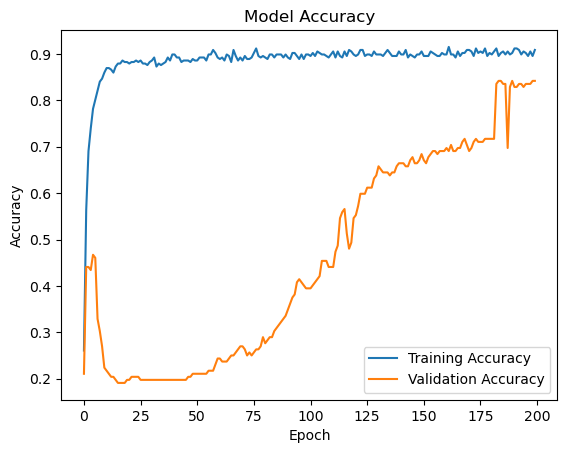

In [324]:
#Change in model accuracy as the model runs through the data
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

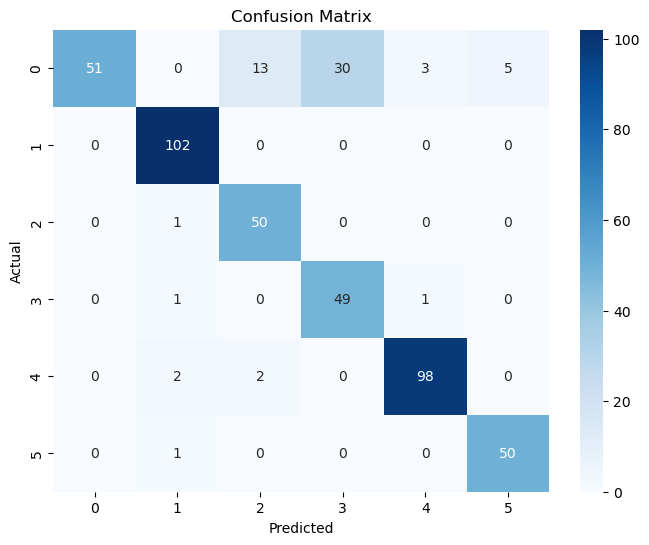

In [325]:
#confusion matrix for the random generated data
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_rand_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

5/5 [==============================] - 0s 2ms/step


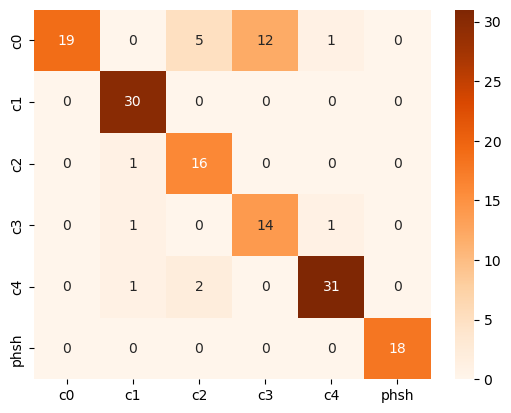

In [331]:
#heat map of model (that used the testing set for validation - not the random generated data)
pred = model.predict(X_test)
y_type_categorical = np.argmax(y_test, axis = 1)
pred_categorical = np.argmax(pred, axis = 1)
confm = confusion_matrix(y_type_categorical, pred_categorical, labels=None)
df_cm = pd.DataFrame(confm, index=labels, columns=labels)
ax = sn.heatmap(df_cm, cmap='Oranges', annot=True, fmt='d')
plt.show()